In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("patient_health_records_raw.csv")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,52.0,Male,North,23.269849,105.399317,191.673672,108.188771,0
1,P0002,43.0,Male,North,26.950777,135.107000,238.738215,94.466565,0
2,P0003,55.0,Female,North,31.400355,125.042174,212.653402,102.267888,0
3,P0004,68.0,NaN,South,23.786439,202.962582,239.305757,109.179880,1
4,P0005,41.0,Male,West,17.555513,107.640968,193.521184,96.235951,0


<h1>Part-A</h1>

<h3>1</h3>

In [20]:
missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

missing_data_report = missing_data_report[missing_data_report['Missing Values'] > 0]

print("Missing Data Summary Report:")
print(missing_data_report)

Missing Data Summary Report:
             Missing Values  Percentage (%)
age                      50             5.0
gender                   60             6.0
region                   70             7.0
bmi                      80             8.0
cholesterol              60             6.0
glucose                  60             6.0


<h3>2</h3>

In [36]:
#Simple Imputer (Numerical)

from sklearn.impute import SimpleImputer
df1 = df.copy()

mean_imputer = SimpleImputer(strategy='mean')
df1['bmi_mean'] = mean_imputer.fit_transform(df1[['bmi']])

median_imputer = SimpleImputer(strategy='median')
df1['bmi_median'] = median_imputer.fit_transform(df1[['bmi']])

print("Mean used:", mean_imputer.statistics_[0])
print("Median used:", median_imputer.statistics_[0])

missing_rows = df1[df1['bmi'].isnull()].index
print(df1.loc[missing_rows, ['bmi', 'bmi_mean', 'bmi_median']].head())

Mean used: 26.265700824921204
Median used: 26.190890677056693
    bmi   bmi_mean  bmi_median
19  NaN  26.265701   26.190891
28  NaN  26.265701   26.190891
30  NaN  26.265701   26.190891
31  NaN  26.265701   26.190891
32  NaN  26.265701   26.190891


In [39]:
#Simple Imputer (Categorical)

df2 = df.copy()

region_imputer = SimpleImputer(strategy='most_frequent')
df2['region_filled'] = region_imputer.fit_transform(df2[['region']]).ravel()

print("Most frequent region:", region_imputer.statistics_[0])

missing_rows = df2[df2['region'].isnull()].index
print(df2.loc[missing_rows, ['region', 'region_filled']].head())

Most frequent region: North
   region region_filled
25    NaN         North
76    NaN         North
77    NaN         North
80    NaN         North
81    NaN         North


In [40]:
#Most Frequent Imputation

df3 = df.copy()

gender_imputer = SimpleImputer(strategy='most_frequent')
df3['gender_filled'] = gender_imputer.fit_transform(df3[['gender']]).ravel()

print("Most common gender:", gender_imputer.statistics_[0])

missing_rows = df3[df3['gender'].isnull()].index
print(df3.loc[missing_rows, ['gender', 'gender_filled']].head())

Most common gender: Female
   gender gender_filled
3     NaN        Female
19    NaN        Female
20    NaN        Female
29    NaN        Female
38    NaN        Female


In [43]:
#Missing Indicator + Random Sample Imputation

df4 = df.copy()
np.random.seed(42)

cols = ['age', 'cholesterol', 'glucose']

for col in cols:
    df4[col + '_missing'] = df4[col].isnull().astype(int)   # 1 = was missing
    null_count = df4[col].isnull().sum()
    random_vals = df4[col].dropna().sample(n=null_count, replace=True, random_state=42).values
    df4.loc[df4[col].isnull(), col] = random_vals

print(df4[['age', 'age_missing']].head(10))
print("\nMissing left:", df4[cols].isnull().sum().sum())

    age  age_missing
0  52.0            0
1  43.0            0
2  55.0            0
3  68.0            0
4  41.0            0
5  41.0            0
6  69.0            0
7  57.0            0
8  38.0            0
9  53.0            0

Missing left: 0


In [44]:
#KNN Imputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

df5 = df.drop(columns=['patient_id']).copy()

le = LabelEncoder()
df5['gender'] = le.fit_transform(df5['gender'].astype(str))
df5['region'] = le.fit_transform(df5['region'].astype(str))

knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imputer.fit_transform(df5), columns=df5.columns)

missing_rows = df[df['bmi'].isnull()].index
print(df_knn.loc[missing_rows, ['age', 'bmi', 'cholesterol', 'glucose']].head())

     age        bmi  cholesterol     glucose
19  24.0  24.558192   190.710509   60.000000
28  36.0  23.350097   210.687584  134.318153
30  36.0  26.185293   179.984327  376.524738
31  73.0  25.701194   178.010933  119.049563
32  45.0  23.955451   232.882097   83.782121


In [46]:
#MICE Algorithm

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(mice_imputer.fit_transform(df5), columns=df5.columns)

print(df_mice.loc[missing_rows, ['age', 'bmi', 'cholesterol', 'glucose']].head())

     age        bmi  cholesterol     glucose
19  24.0  26.262160   190.710509   60.000000
28  36.0  26.271707   210.687584  134.318153
30  36.0  26.277746   179.984327  376.524738
31  73.0  26.267396   178.010933  119.049563
32  45.0  26.265317   232.882097   83.782121


<h1>Part-B</h1>

<h3>3</h3>

In [47]:
#Z-Score Method

dfb = df.copy()

for col in ['cholesterol', 'glucose']:
    mean_val = dfb[col].mean()
    std_val = dfb[col].std()
    dfb[col + '_zscore'] = (dfb[col] - mean_val) / std_val

threshold = 3
outliers_chol = dfb[dfb['cholesterol_zscore'].abs() > threshold]
outliers_glucose = dfb[dfb['glucose_zscore'].abs() > threshold]

print("Cholesterol outliers found:", len(outliers_chol))
print("Glucose outliers found:", len(outliers_glucose))

df_zscore_clean = dfb[(dfb['cholesterol_zscore'].abs() <= threshold) &
                       (dfb['glucose_zscore'].abs() <= threshold)].copy()

print("Rows before:", len(dfb), "| Rows after:", len(df_zscore_clean))
print("Mean cholesterol BEFORE:", round(dfb['cholesterol'].mean(), 1))
print("Mean cholesterol AFTER: ", round(df_zscore_clean['cholesterol'].mean(), 1))

Cholesterol outliers found: 15
Glucose outliers found: 13
Rows before: 1000 | Rows after: 862
Mean cholesterol BEFORE: 199.8
Mean cholesterol AFTER:  199.7


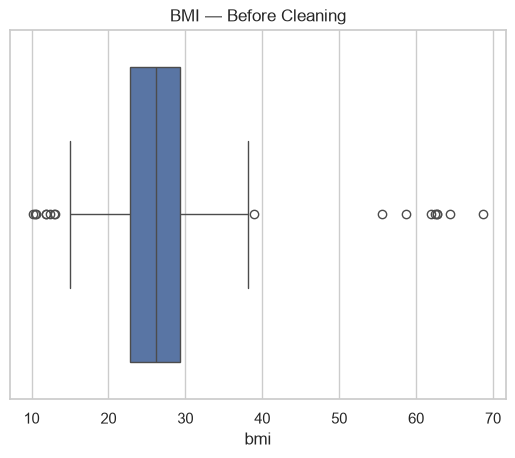

Lower fence: 13.154088718937736 | Upper fence: 38.90034050914672
BMI outliers found: 17
Rows before: 1000 | Rows after: 983


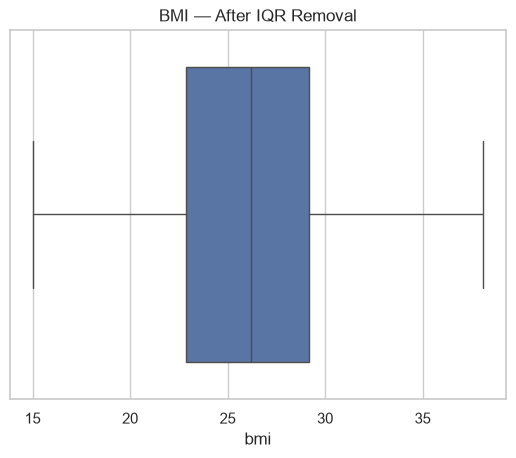

In [48]:
#IQR Method

import seaborn as sns
import matplotlib.pyplot as plt

dfc = df.copy()

sns.boxplot(data=dfc, x='bmi')
plt.title('BMI — Before Cleaning')
plt.show()

Q1 = dfc['bmi'].quantile(0.25)
Q3 = dfc['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
print("Lower fence:", lower_fence, "| Upper fence:", upper_fence)

outlier_mask = (dfc['bmi'] < lower_fence) | (dfc['bmi'] > upper_fence)
print("BMI outliers found:", outlier_mask.sum())

df_iqr_clean = dfc[~outlier_mask].copy()
print("Rows before:", len(dfc), "| Rows after:", len(df_iqr_clean))

sns.boxplot(data=df_iqr_clean, x='bmi')
plt.title('BMI — After IQR Removal')
plt.show()

In [49]:
#Percentile Method

dfd = df.copy()

lower_bound = dfd['bmi'].quantile(0.01)
upper_bound = dfd['bmi'].quantile(0.99)
print("1st percentile:", lower_bound, "| 99th percentile:", upper_bound)

dfd['bmi_capped'] = dfd['bmi'].clip(lower=lower_bound, upper=upper_bound)

print("BMI before - min:", dfd['bmi'].min(), "max:", dfd['bmi'].max())
print("BMI after  - min:", dfd['bmi_capped'].min(), "max:", dfd['bmi_capped'].max())

1st percentile: 15.0 | 99th percentile: 37.963488556813545
BMI before - min: 10.13182602388415 max: 68.75751659789279
BMI after  - min: 15.0 max: 37.963488556813545


<h3>4</h3>

In [51]:
#Winsorization

from scipy.stats.mstats import winsorize

dfe = df.copy()

dfe['cholesterol_wins'] = winsorize(dfe['cholesterol'].fillna(dfe['cholesterol'].median()), limits=[0.01, 0.01])
dfe['glucose_wins'] = winsorize(dfe['glucose'].fillna(dfe['glucose'].median()), limits=[0.01, 0.01])

print("Rows before:", len(dfe), "| Rows after:", len(dfe))
print("Cholesterol before - min:", dfe['cholesterol'].min(), "max:", dfe['cholesterol'].max())
print("Cholesterol after  - min:", dfe['cholesterol_wins'].min(), "max:", dfe['cholesterol_wins'].max())

Rows before: 1000 | Rows after: 1000
Cholesterol before - min: 42.90919907521854 max: 441.335316567649
Cholesterol after  - min: 120.0 max: 287.5452066518028


<h3>5</h3>

In [53]:
print("Original shape:", df.shape)
print("After Z-score removal:", df_zscore_clean.shape)
print("After IQR removal:", df_iqr_clean.shape)

print("\nOriginal BMI summary:\n", df['bmi'].describe())
print("\nAfter IQR BMI summary:\n", df_iqr_clean['bmi'].describe())

Original shape: (1000, 9)
After Z-score removal: (862, 11)
After IQR removal: (983, 9)

Original BMI summary:
 count    920.000000
mean      26.265701
std        5.823598
min       10.131826
25%       22.808933
50%       26.190891
75%       29.245496
max       68.757517
Name: bmi, dtype: float64

After IQR BMI summary:
 count    903.000000
mean      26.063032
std        4.570177
min       15.000000
25%       22.866950
50%       26.185965
75%       29.149795
max       38.118651
Name: bmi, dtype: float64


<h1>Part-C</h1>

<h3>6</h3>

In [54]:
df_final = df.copy()

df_final = df_final.fillna(df_final.median(numeric_only=True))
df_final['gender'] = df_final['gender'].fillna(df_final['gender'].mode()[0])
df_final['region'] = df_final['region'].fillna(df_final['region'].mode()[0])

for col in ['bmi', 'blood_pressure', 'cholesterol', 'glucose']:
    df_final[col] = df_final[col].clip(df_final[col].quantile(0.01), df_final[col].quantile(0.99))

print("Missing values left:", df_final.isnull().sum().sum())
print("Final shape:", df_final.shape)

df_final.to_csv("patient_health_records_clean_final.csv", index=False)
df_final.head()

Missing values left: 0
Final shape: (1000, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,52.0,Male,North,23.269849,105.399317,191.673672,108.188771,0
1,P0002,43.0,Male,North,26.950777,135.107000,238.738215,94.466565,0
2,P0003,55.0,Female,North,31.400355,125.042174,212.653402,102.267888,0
3,P0004,68.0,Female,South,23.786439,202.962582,239.305757,109.179880,1
4,P0005,41.0,Male,West,17.555513,107.640968,193.521184,96.235951,0


<h3>7</h3>

Data Cleaning Report


For missing values, we tested six strategies: mean/median imputation, most frequent imputation, missing indicator + random sampling, KNN imputation, and MICE. Among these, KNN and MICE were the most effective, since they use relationships between multiple columns (e.g., age, BMI, cholesterol together) to estimate missing values, rather than filling every gap with one fixed number like mean/mode does. Simple mean/median imputation was easiest to implement but risks distorting the data's natural spread, especially in columns that also contain outliers (like BMI).


For outliers, we tested Z-score and IQR removal, percentile capping, and Winsorization. Percentile capping and Winsorization preserved data quality best, because they kept all 1000 patient records intact by capping extreme values instead of deleting rows — Z-score and IQR removal both reduced the dataset size, which risks losing real patients along with genuine outlier errors.


Overall, cleaning the dataset improved usability by removing unrealistic extreme values (e.g., BMI of 70, blood pressure of 250) that could have skewed a machine learning model, and by ensuring every column was complete so the dataset is ready for training a model to predict disease_risk without errors from missing data.